#### **What is keras callbacks?**

A callback is an object (a class instance implementing specific methods) that is passed to the model in the call to fit and that is called by the model at various points during training. It has access to all the available data about the state of the model and its performance, and it can take action: interrupt training, save a model, load a different weight set, or otherwise alter the state of the model.

Lets define the callbacks one-by-one and used them in a real world scenario.

#### **The Model Checkpoint and Early Stopping Callbacks**

Model Checkpointing save the current weight and and early stopping interrrupting training when validation loss is no longer improving.

In [34]:
import keras
from keras import layers
from keras.datasets import mnist
import numpy as np

# Callbacks are passed to the model via the callbacks argument in the fit,
# which takes a list of callbacks. We can pass any number of callbacks

callbacks_list = [
    keras.callbacks.EarlyStopping(# Interrupts training when improvement stops
        monitor='val_accuracy', # Monitor the model's validation accuracy
        patience=1, # Interrupts training when accuracy has stopped improving more than one epoch
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(# Saves the current weights after every epoch
        filepath='my_mnist_model.h5', #path to the destination model file
        monitor = 'val_loss',
        save_best_only=True,
        verbose=1
    )
]

# 1. Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

# 2. Build a simple Keras model
def build_model():
    model = keras.Sequential(
        [
            keras.Input(shape=(28, 28, 1)),
            layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
            layers.MaxPooling2D(pool_size=(2, 2)),
            layers.Flatten(),
            layers.Dropout(0.5),
            layers.Dense(10, activation="softmax"),
        ]
    )
    return model

model = build_model()
model.summary()

# 3. Compile the model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# 4. Train the model with callbacks
epochs = 5 # Reduced for quicker demonstration
batch_size = 128

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    callbacks=callbacks_list
)

print("\nTraining finished. Model checkpointed to 'my_mnist_model.h5' if improvement occurred.")
print("Early stopping might have been triggered if validation accuracy did not improve.")

# Evaluate the model on the test set
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

# To load the best model:
from keras.models import load_model
best_model = load_model('my_mnist_model.h5')
print("Loaded best model accuracy:", best_model.evaluate(x_test, y_test, verbose=0)[1])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

...


Epoch 2: finished saving model to my_mnist_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9653 - loss: 0.1128 - val_accuracy: 0.9842 - val_loss: 0.0613
Epoch 3/5
415/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9735 - loss: 0.0869
Epoch 3: val_loss improved from 0.06134 to 0.05367, saving model to my_mnist_model.h5



Epoch 3: finished saving model to my_mnist_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9741 - loss: 0.0858 - val_accuracy: 0.9845 - val_loss: 0.0537
Epoch 4/5
409/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9769 - loss: 0.0748
Epoch 4: val_loss improved from 0.05367 to 0.04671, saving model to my_mnist_model.h5



Epoch 4: finished saving model to my_mnist_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9769 - loss: 0.0737 - val_accuracy: 0.9888 - val_loss: 0.0467
Epoch 5/5
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9799 - loss: 0.0648
Epoch 5: val_loss improved from 0.04671 to 0.04174, saving model to my_mnist_model.h5



Epoch 5: finished saving model to my_mnist_model.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9801 - loss: 0.0643 - val_accuracy: 0.9887 - val_loss: 0.0417
Epoch 5: early stopping

Training finished. Model checkpointed to 'my_mnist_model.h5' if improvement occurred.
Early stopping might have been triggered if validation accuracy did not improve.


Test loss: 0.03677213937044144
Test accuracy: 0.9872999787330627
Loaded best model accuracy: 0.9872999787330627


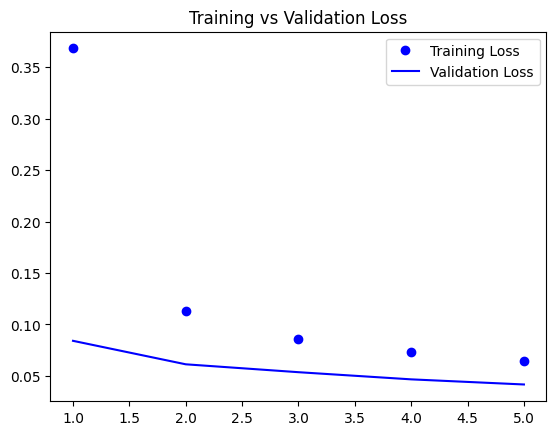

In [35]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, 6)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

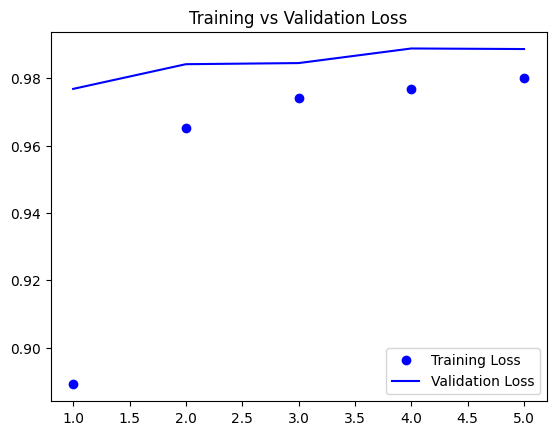

In [36]:
### Plotting Results
import matplotlib.pyplot as plt

loss = history.history['accuracy']
val_loss = history.history['val_accuracy']

epochs = range(1, 6)

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

#### **The Reduce Plateu Callback**

We can use this callback to reduce the learning rate when the validation loss has stopped improving. Reducing or increasing the learning rate in casse of a loss plateau is an effective strategy to get out of local minima during training.

In [37]:
callbacks_list = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.1,
        patience=1,
    )
]

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=20,
    validation_split=0.1,
    callbacks=callbacks_list
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9820 - loss: 0.0578 - val_accuracy: 0.9898 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9838 - loss: 0.0519 - val_accuracy: 0.9903 - val_loss: 0.0342 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9834 - loss: 0.0510 - val_accuracy: 0.9898 - val_loss: 0.0364 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9874 - loss: 0.0403 - val_accuracy: 0.9905 - val_loss: 0.0333 - learning_rate: 1.0000e-04
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9878 - loss: 0.0391 - val_accuracy: 0.9912 - val_loss: 0.0335 - learning_rate: 1.0000e-04
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9876 - loss: 0.0381 - val_accuracy: 0.9910 - val_loss: 0.0334 - learning_rate: 1.0000e-05
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9878 - los

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


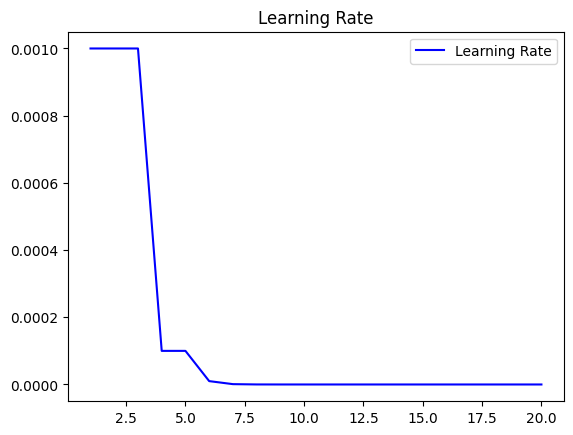

In [38]:
### Plotting Results
import matplotlib.pyplot as plt
print(history.history.keys())
#loss = history.history['val_accuracy']
val_loss = history.history['learning_rate']

epochs = range(1, 21)

plt.figure()

#plt.plot(epochs, loss, 'bo', label='Validation Loss')
plt.plot(epochs, val_loss, 'b', label='Learning Rate')
plt.title('Learning Rate')
plt.legend()

plt.show()

#### **Customized Callbacks**

For interpretability it is important to study the attention. Let's design a customized callbacks for it.

In [39]:
# ============================================================
# Activation Logger Callback
# ============================================================

class ActivationLogger(keras.callbacks.Callback):

    def __init__(self, sample):
        super().__init__()
        self.sample = sample

    def set_model(self, model):
        super().set_model(model)

        self.activations_model = keras.Model(
            inputs=model.inputs,
            outputs=[layer.output for layer in model.layers]
        )

    def on_epoch_end(self, epoch, logs=None):

        activations = self.activations_model.predict(
            self.sample,
            verbose=0
        )

        np.savez(
            f"activations_at_epoch_{epoch+1}.npz",
            **{
                f"arr_{i}": activation
                for i, activation in enumerate(activations)
            }
        )

        print(
            f"Saved activations for epoch {epoch+1}"
        )

In [40]:
# ============================================================
# Create Model
# ============================================================

model = build_model()

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Sample whose activations will be tracked
activation_sample = x_test[:1]

activation_logger = ActivationLogger(
    sample=activation_sample
)

In [41]:
# ============================================================
# Train
# ============================================================

epochs = 3

history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    callbacks=[activation_logger],
    verbose=1
)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7639 - loss: 0.7557Saved activations for epoch 1
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8915 - loss: 0.3561 - val_accuracy: 0.9753 - val_loss: 0.0868
Epoch 2/3
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9646 - loss: 0.1179Saved activations for epoch 2
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9673 - loss: 0.1069 - val_accuracy: 0.9837 - val_loss: 0.0554
Epoch 3/3
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9731 - loss: 0.0846Saved activations for epoch 3
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9746 - loss: 0.0816 - val_accuracy: 0.9875 - val_loss: 0.0450



Loading activations...
Saved arrays:
['arr_0', 'arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6']
Activation tensor shape: (26, 26, 32)


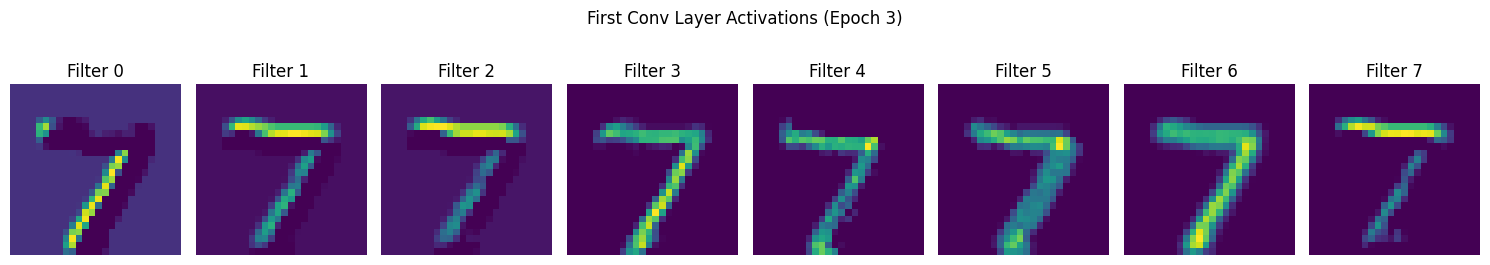

In [42]:
# ============================================================
# Visualize First Conv Layer Activations
# ============================================================

epoch_to_visualize = epochs
activation_file = f"activations_at_epoch_{epoch_to_visualize}.npz"

print("\nLoading activations...")

data = np.load(activation_file)

print("Saved arrays:")
print(data.files)

# Since model.layers does NOT include Input layer,
# arr_0 corresponds to Conv2D(conv1)
first_conv_activations = data["arr_0"][0]

print(
    f"Activation tensor shape: "
    f"{first_conv_activations.shape}"
)

num_filters = first_conv_activations.shape[-1]
num_plots = min(8, num_filters)

fig, axes = plt.subplots(
    1,
    num_plots,
    figsize=(15, 3)
)

if num_plots == 1:
    axes = [axes]

for i in range(num_plots):

    axes[i].imshow(
        first_conv_activations[:, :, i],
        cmap="viridis"
    )

    axes[i].set_title(f"Filter {i}")
    axes[i].axis("off")

plt.suptitle(
    f"First Conv Layer Activations (Epoch {epoch_to_visualize})"
)

plt.tight_layout()
plt.show()

#### **Introduction to Tensorboard**

Let's demonstrate these features on a simple example. We'll train a 1D convnet on the IMDB sentiment-analysis task.

In [43]:
### Text-classification model to use with TensorBoard

import keras
from keras import layers
from keras.datasets import imdb
from keras.preprocessing import sequence

max_features = 2000
max_len = 500

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
x_train = sequence.pad_sequences(x_train, maxlen=max_len)
x_test = sequence.pad_sequences(x_test, maxlen=max_len)

model = keras.models.Sequential()
model.add(layers.Embedding(max_features,128, input_length=max_len,name='embed'))
model.add(layers.Conv1D(32, 7, activation='relu'))
model.add(layers.MaxPooling1D(5))
model.add(layers.Conv1D(32, 7, activation='relu'))
model.add(layers.GlobalMaxPooling1D())
model.add(layers.Dense(1))
model.summary()
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embed (Embedding)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [44]:
### Training the model with a TensorBoard callback

callbacks = [
    keras.callbacks.TensorBoard(
        log_dir='./',
        histogram_freq=1,
        embeddings_freq=1,
    )
]

history = model.fit(x_train, y_train,
                   epochs=20,
                   batch_size=128,
                   validation_split=0.2,
                   callbacks=callbacks)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - acc: 0.6586 - loss: 0.6336 - val_acc: 0.7950 - val_loss: 0.5382
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8334 - loss: 0.4840 - val_acc: 0.8504 - val_loss: 0.4243
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.8699 - loss: 0.4018 - val_acc: 0.8640 - val_loss: 0.4576
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - acc: 0.8929 - loss: 0.3364 - val_acc: 0.8582 - val_loss: 0.5041
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - acc: 0.9118 - loss: 0.2953 - val_acc: 0.8694 - val_loss: 0.5302
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.9312 - loss: 0.2503 - val_acc: 0.8638 - val_loss: 0.6328
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - acc: 0.9398 - loss: 0.2314 - val_acc: 0.8422 - val_loss: 0.9080
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.9572 - loss: 0.1947 - val_acc: 0.8688 - val_loss: 0.6982
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms

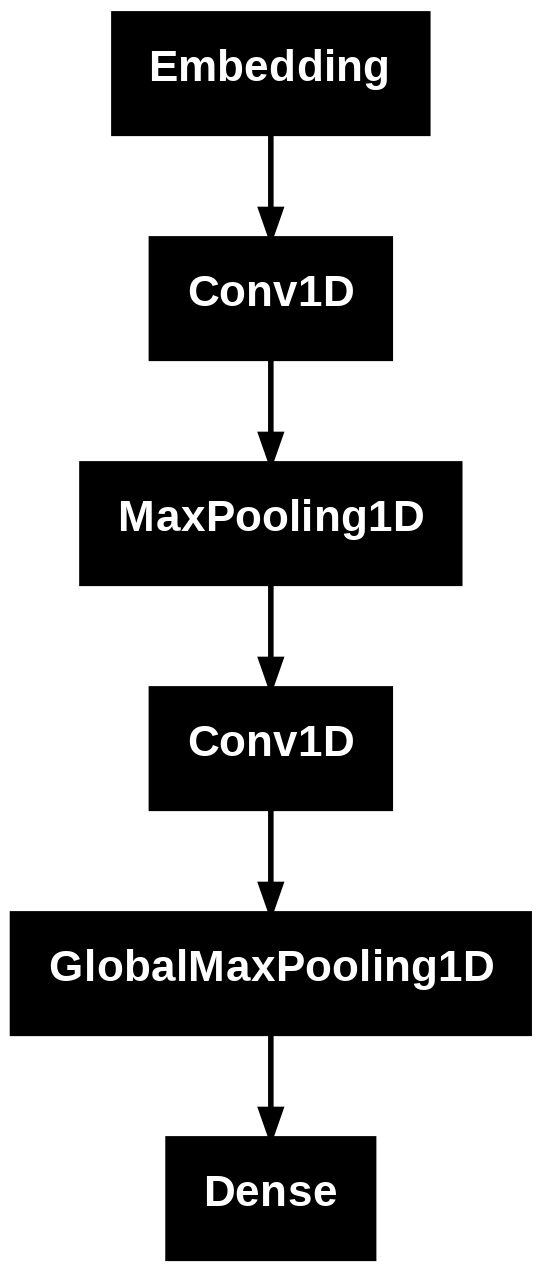

In [45]:
from keras.utils import plot_model
plot_model(model, to_file='model.png')

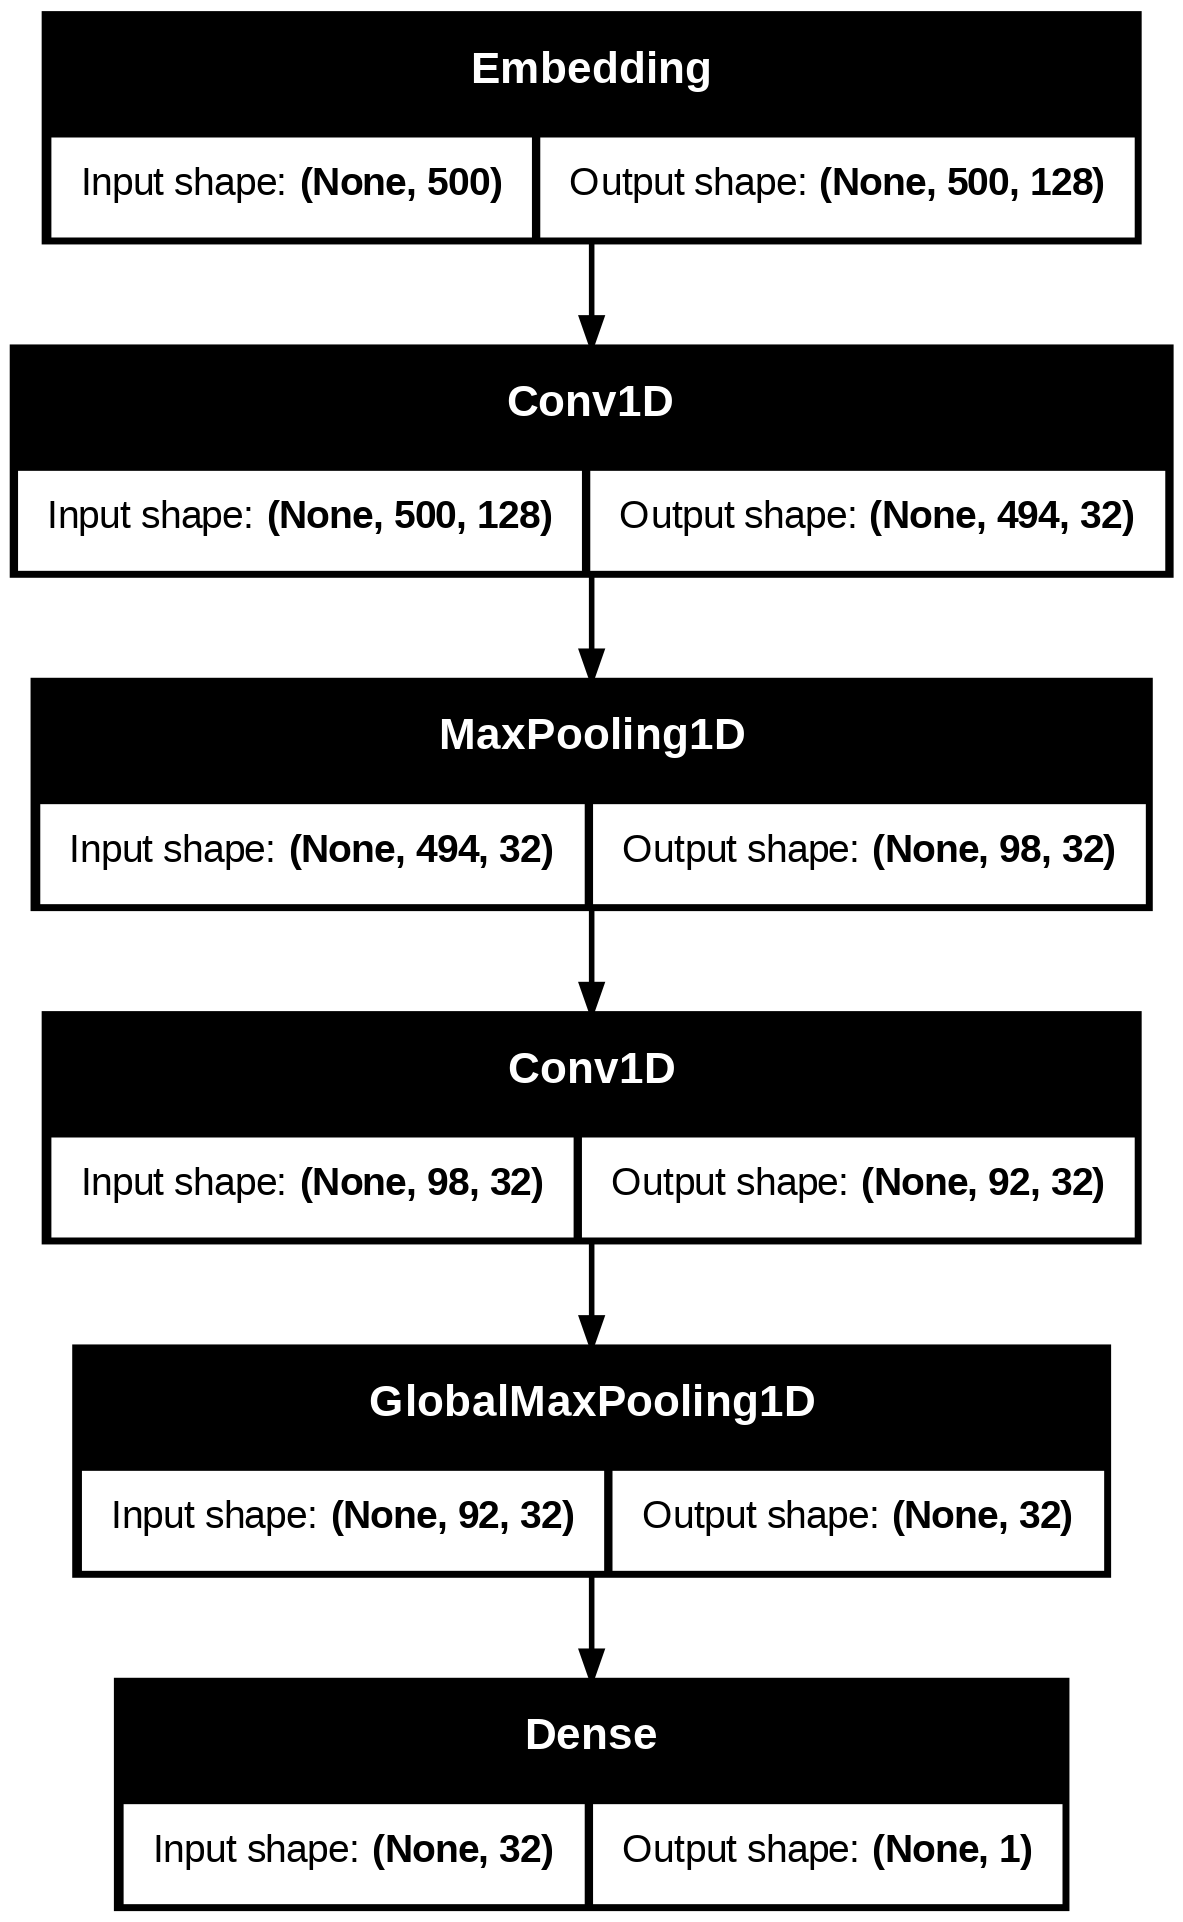

In [46]:
from keras.utils import plot_model

plot_model(model, show_shapes=True, to_file='model_i.png')

#### **Wrapping up**

Keras callbacks provide a simple way to monitor models during training and automatically take action based on the state of the model.